In [1]:
import pickle
import os

import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
# Carga del dataset
digits = datasets.load_digits()

In [3]:
# Tamaño del dataset
digits.images.shape

(1797, 8, 8)

In [4]:
# Ejemplo de una imagen del dataset
digits.images[0, :, :]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [5]:
# Clases
set(digits.target)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

In [6]:
# Ejemplo de una imagen del dataset
plt.figure()
plt.imshow(digits.images[0], cmap=plt.cm.binary)
plt.grid(False)
plt.show()

<Figure size 640x480 with 1 Axes>

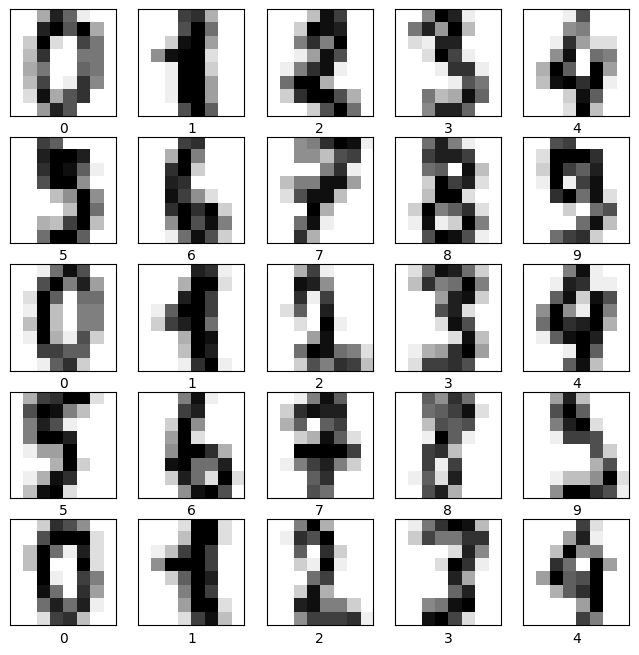

In [7]:
plt.figure(figsize=(8,8))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(digits.images[i], cmap=plt.cm.binary)
    plt.xlabel(digits.target[i])
plt.show()

In [8]:
# Preparación de los datos
# Cambio de las dimensiones de los datos

n_samples = len(digits.images)
# El dataset de imágenes tiene 8x8 píxeles, por lo que se debe cambiar la forma de los datos a (n_samples, 64)
data = digits.images.reshape((n_samples, -1))
# El -1 en reshape indica que se debe calcular automáticamente el tamaño de esa dimensión en función del tamaño de las otras dimensiones y del número total de elementos en el array. En este caso, se está indicando que la segunda dimensión debe ser calculada automáticamente para que el número total de elementos en el array sea igual a n_samples * 64.
data.shape

(1797, 64)

In [9]:
# Particionamiento de los datos en entrenamiento y prueba


X_train, X_test, y_train, y_test = train_test_split(
    data, 
    digits.target, 
    test_size=0.2, 
    shuffle=True, 
    )

In [10]:
# Estimación del modelo
# Se usa un modelo de regresión logística para la clasificación de los dígitos. Se establece un número máximo de iteraciones para asegurar la convergencia del algoritmo.
# Se usa este porque es un modelo lineal que puede manejar múltiples clases y es eficiente para conjuntos de datos pequeños a medianos como el conjunto de dígitos.
estimator = LogisticRegression(max_iter=1000)

estimator.fit(
    X_train, 
    y_train
    )

# Precisión para la muestra de entrenamiento
accuracy_score(y_true=y_train, y_pred=estimator.predict(X_train))

1.0

In [11]:
# Precisión para la muestra de prueba
predictions = estimator.predict(X_test)
predicted_proba = estimator.predict_proba(X_test)

accuracy_score(y_true=y_test, y_pred=predictions)

0.9583333333333334

Confusion matrix:
[[32  0  0  0  0  0  0  0  0  0]
 [ 0 38  0  1  0  0  0  0  1  0]
 [ 0  0 37  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  2  0  0  0  1]
 [ 0  0  0  0 38  0  1  0  0  0]
 [ 0  0  1  0  0 31  0  0  0  1]
 [ 0  0  0  0  0  0 47  0  0  0]
 [ 0  0  0  0  0  0  0 27  0  0]
 [ 0  2  1  0  1  1  0  0 30  0]
 [ 0  0  0  0  0  1  0  0  1 32]]


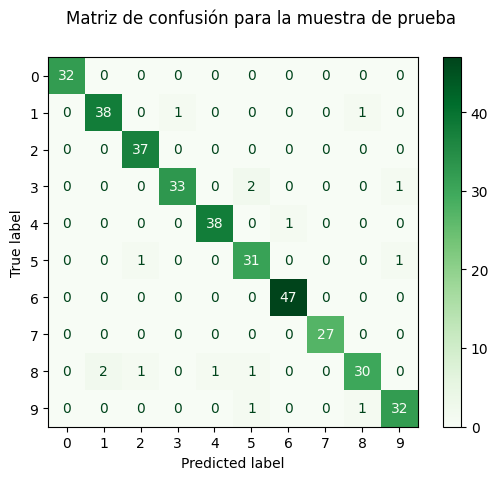

In [12]:
# Matriz de confusión para la muestra de prueba

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    predictions,
    cmap='Greens'
)

disp.figure_.suptitle("Matriz de confusión para la muestra de prueba")
print(f'Confusion matrix:\n{disp.confusion_matrix}'                                                                                     )

In [13]:
def plot_image(i, predicted_label, true_label, predicted_proba, img):

    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    if predicted_label[i] == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel(
        "{} {:2.0f}% ({})".format(
        predicted_label[i],
        100*max(predicted_proba[i, :]),
        true_label),
        color=color
    )         

def plot_value_array(i, predicted_proba, predicted_label, true_label):
    #
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predicted_proba[i], color="#777777")
    plt.ylim([0, 1])
    #
    thisplot[predicted_label[i]].set_color('red')
    thisplot[true_label[i]].set_color('blue')
                                                                                                         

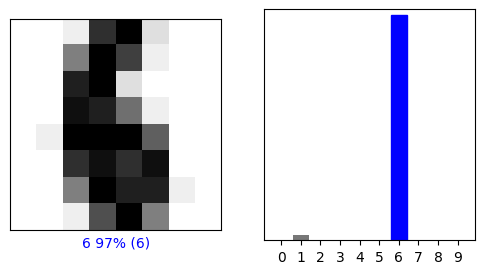

In [14]:
i = 3
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions, y_test, predicted_proba, X_test.reshape(len(X_test), 8, 8))
plt.subplot(1,2,2)
plot_value_array(i, predicted_proba, predictions, y_test)
plt.show()

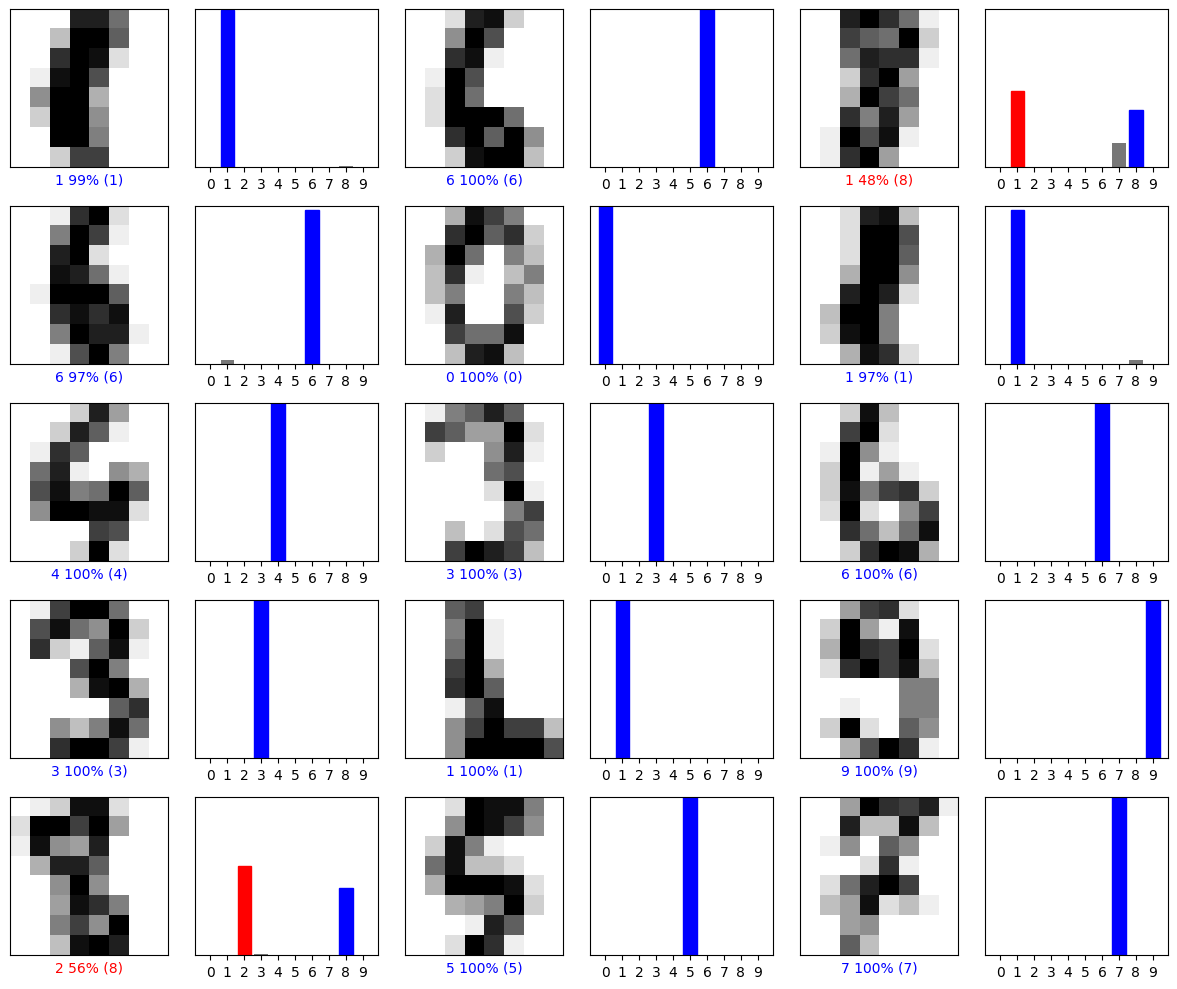

In [15]:
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols

plt.figure(figsize=(2*2*num_cols, 2*num_rows))

for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions, y_test, predicted_proba, X_test.reshape(len(X_test), 8, 8))
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predicted_proba, predictions, y_test)
plt.tight_layout()

In [16]:
# Almacenamiento del modelo entrenado

with open('../submission/estimator.pkl', 'wb') as f:
    pickle.dump(estimator, f)

In [17]:
# Uso del modelo
with open('../submission/estimator.pkl', 'rb') as f:
    new_clf = pickle.load(f)

accuracy_score(
    y_true=digits.target,
    y_pred=new_clf.predict(data)
)

0.991652754590985